# Cardiac LGE Clustering — Model Comparison

This notebook runs inference using all pre-trained models on the Cardiac LGE scar mapping dataset and compares their clustering performance.

**Models**: Baseline GMM, VAE-GMM, Diffusion-VAE, Ours  
**Metrics**: Accuracy (Hungarian), NMI, ARI  
**Clusters**: K=5 pathologies (Healthy, Ischemic Subendo, Ischemic Transmural, DCM Mid-wall, Myocarditis Epicardial)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from notebook_utils import (
    run_all_models, build_metrics_table, plot_cluster_means_grid,
    plot_all_models_cluster_samples, compute_cluster_purity_table,
    save_results_cache, MODEL_DISPLAY_NAMES,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load Data & Run All Models

We evaluate on the cardiac test set (20% holdout, 128x128 LGE images). For each model we extract features, fit a GMM with K=5, and assign clusters.

For Diffusion-VAE, we use denoised latents at t=2 (best performing timestep).

In [2]:
MODEL_ORDER = ['baseline_gmm', 'vae_gmm', 'diffusion_vae', 'ours']

print('Running inference on all models...')
results, (test_loader, dataset_info) = run_all_models('cardiac', MODEL_ORDER, device)
print(f'\nModels evaluated: {[results[m]["display_name"] for m in MODEL_ORDER if m in results]}')

# Cache cluster assignments
save_results_cache(results, 'cardiac')

Running inference on all models...
  Loading Baseline GMM... Loaded cardiac dataset:
  - Training samples: 4000
  - Test samples: 1000
  - Num classes: 5
  - Image size: (1, 128, 128)
  - Batch size: 64
done
  Loading VAE-GMM... done
  Loading Diffusion-VAE... done
  Loading Ours... done

Models evaluated: ['Baseline GMM', 'VAE-GMM', 'Diffusion-VAE', 'Ours']


## 2. Performance Metrics

Comparing clustering performance across all models using Hungarian accuracy, NMI, and ARI.

In [3]:
metrics_df = build_metrics_table(results, supervised=True)
metrics_df

,Accuracy,NMI,ARI
Model,,,
Baseline GMM,0.3450,0.3437,0.1788
VAE-GMM,0.7880,0.8310,0.7464
Diffusion-VAE,0.8000,0.8314,0.7567
Ours,0.8880,0.8074,0.7819


## 3. Cluster Means Comparison

Each row shows the 5 cluster prototypes for one model. Neural models decode from latent space; the baseline uses pixel-space centroids.

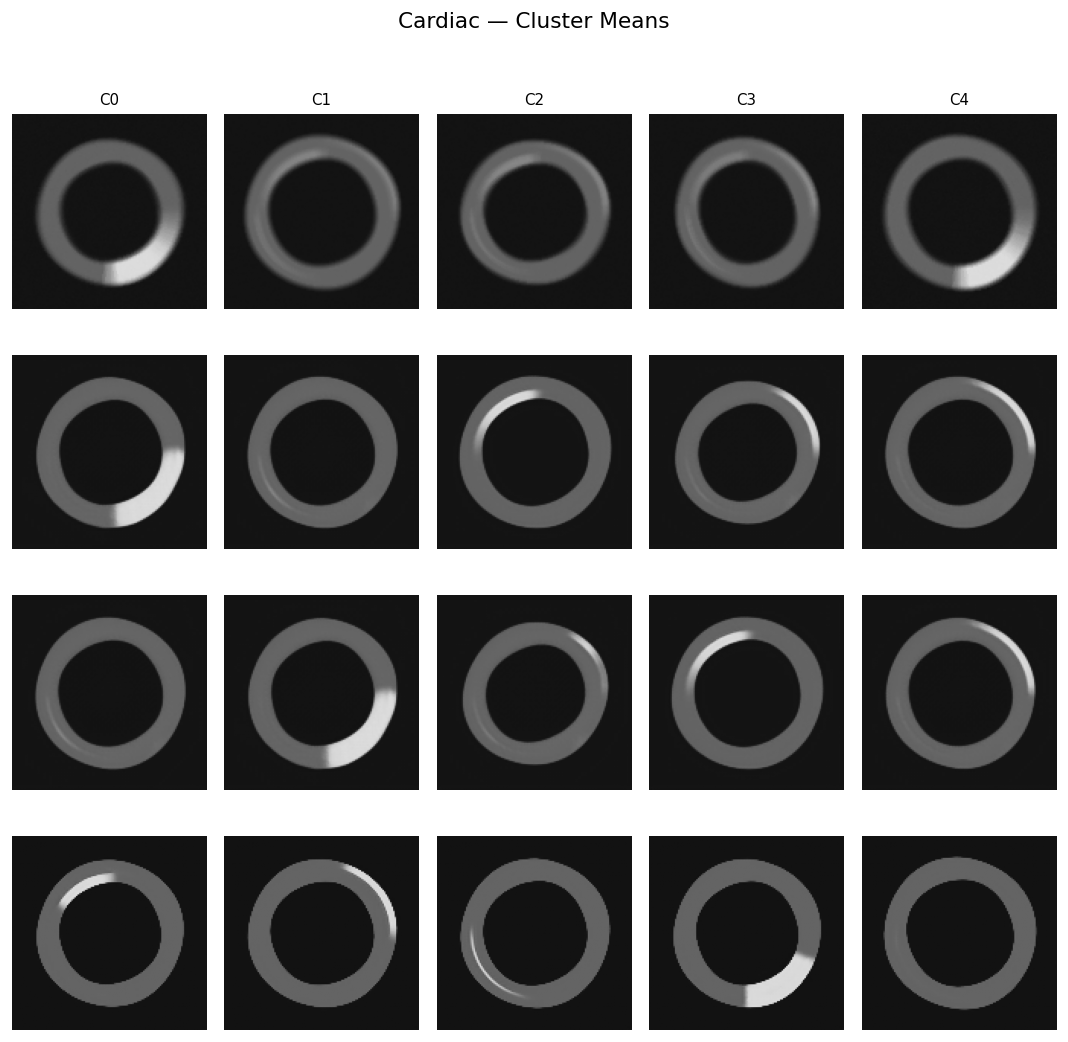

In [4]:
plot_cluster_means_grid(results, MODEL_ORDER, device, title='Cardiac — Cluster Means')

## 4. Cluster Purity

Per-cluster breakdown for each model, showing which pathology class dominates and the purity ratio.

In [6]:
for mname in MODEL_ORDER:
    if mname not in results:
        continue
    r = results[mname]
    print(f"\n{'='*60}")
    print(f"{r['display_name']}")
    print(f"{'='*60}")
    purity_df = compute_cluster_purity_table(
        r['labels'], r['cluster_labels'], r['num_clusters'], dataset_info['class_names']
    )
    # Pretty-print purity table without pandas .style, which requires jinja2
    # Instead, format numbers manually and print as text
    purity_df_to_print = purity_df.copy()
    if 'Purity' in purity_df_to_print.columns:
        purity_df_to_print['Purity'] = (purity_df_to_print['Purity'] * 100).map('{:.2f}%'.format)
    print(purity_df_to_print.to_string(index=False))


Baseline GMM
 Cluster  Count                 Dominant  Purity  Healthy  Ischemic (Subendo)  Ischemic (Transmural)  DCM (Mid-wall Line)  Myocarditis (Epicardial)
       0    120    Ischemic (Transmural) 100.00%        0                   0                    120                    0                         0
       1    356      DCM (Mid-wall Line)  28.09%       81                  94                      0                  100                        81
       2    219       Ischemic (Subendo)  29.68%       50                  65                      0                   48                        56
       3    201 Myocarditis (Epicardial)  29.85%       47                  41                      0                   53                        60
       4    104    Ischemic (Transmural) 100.00%        0                   0                    104                    0                         0

VAE-GMM
 Cluster  Count                 Dominant  Purity  Healthy  Ischemic (Subendo)  Ischemic (

## 5. Cluster Samples

Change `CLUSTER_IDX` below and re-run the cell to browse samples from different clusters.


Baseline GMM — Cluster 1 (356 samples)


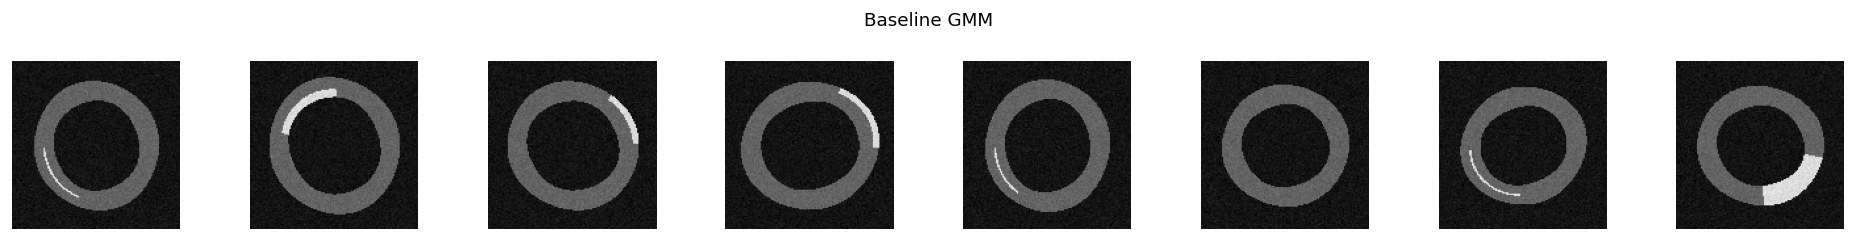


VAE-GMM — Cluster 1 (350 samples)


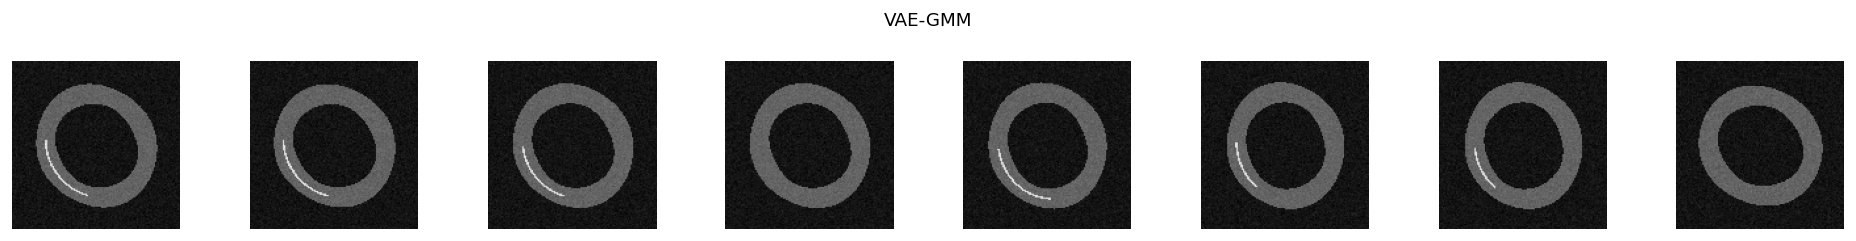


Diffusion-VAE — Cluster 1 (224 samples)


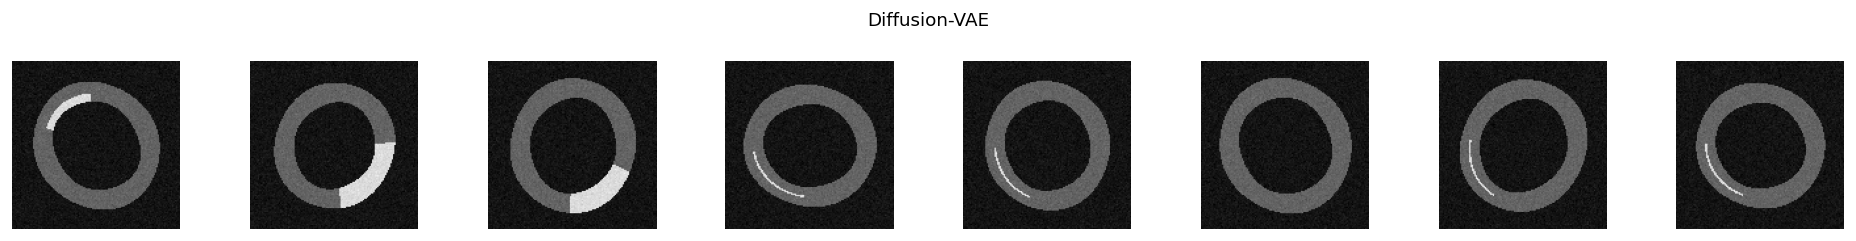


Ours — Cluster 1 (197 samples)


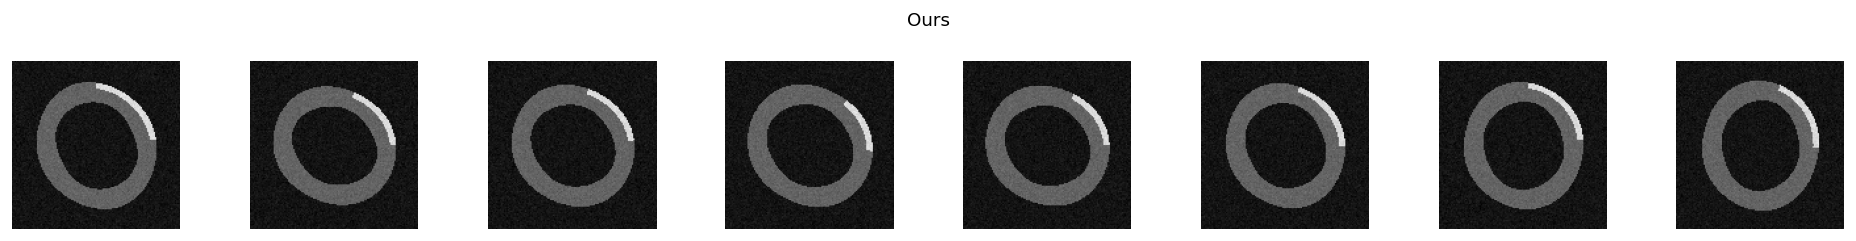

In [8]:
CLUSTER_IDX = 1  # <-- Change this value (0-4) and re-run

plot_all_models_cluster_samples(results, MODEL_ORDER, CLUSTER_IDX, n_samples=8)

## Analysis

**Key observations:**

- **Baseline GMM** in pixel space (16,384D) struggles with the high-dimensional cardiac images. Cluster means are extremely blurry and purity is low.

- **VAE-GMM** compresses images to a 16D latent space where GMM clustering separates pathologies more effectively. Decoded cluster means show recognizable cardiac patterns.

- **Diffusion-VAE** refines the latent space with a denoiser (best at t=2). This can sharpen the cluster boundaries in the latent space.

- **Ours** achieves the highest performance with manifold-aware clustering. The heat-kernel medoid selection ensures cluster prototypes remain on the data manifold, producing the sharpest and most clinically interpretable prototypes.